RQ1. Does the AI resource allocation model show unequal prediction outcomes across gender groups?

RQ2. Does the model show unequal prediction outcomes across racial groups?

RQ3. How do different machine learning models compare in terms of accuracy and fairness?

RQ4. Can fairness-aware mitigation reduce demographic bias without causing a large loss in prediction performance?

RQ5. What is the trade-off between model performance and fairness in AI-based resource allocation?

In [3]:
import os

os.makedirs("figures_pdf", exist_ok=True)
os.makedirs("tables_csv", exist_ok=True)
os.makedirs("poster", exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

adult = fetch_ucirepo(id=2)

X = adult.data.features
y = adult.data.targets

df = pd.concat([X, y], axis=1)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

df.head()

(48842, 15)

Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null 

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
print(df.shape)
print(df.columns.tolist())

(48842, 15)
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


In [7]:
# Check unique values in income column
print(df["income"].unique())

# Replace ? with NaN
df = df.replace("?", np.nan)

# Remove rows with missing values
df = df.dropna()

# Create binary target
df["income_binary"] = df["income"].apply(
    lambda x: 1 if ">50K" in str(x) else 0
)

print("New Shape:", df.shape)

print("\nIncome Distribution:")
print(df["income_binary"].value_counts())

df.head()

['<=50K' '>50K' '<=50K.' '>50K.']
New Shape: (45222, 16)

Income Distribution:
income_binary
0    34014
1    11208
Name: count, dtype: int64


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_binary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


In [8]:
print(df.shape)
print(df["income_binary"].value_counts())

(45222, 16)
income_binary
0    34014
1    11208
Name: count, dtype: int64


In [9]:
summary_table = pd.DataFrame({
    "Metric": [
        "Number of Rows",
        "Number of Columns",
        "Positive Class (>50K)",
        "Negative Class (<=50K)",
        "Protected Attribute 1",
        "Protected Attribute 2"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        (df["income_binary"] == 1).sum(),
        (df["income_binary"] == 0).sum(),
        "sex",
        "race"
    ]
})

summary_table

,Metric,Value
0,Number of Rows,45222
1,Number of Columns,16
2,Positive Class (>50K),11208
3,Negative Class (<=50K),34014
4,Protected Attribute 1,sex
5,Protected Attribute 2,race


In [10]:
summary_table.to_csv(
    "tables_csv/table1_dataset_summary.csv",
    index=False
)

print("CSV saved successfully")

CSV saved successfully


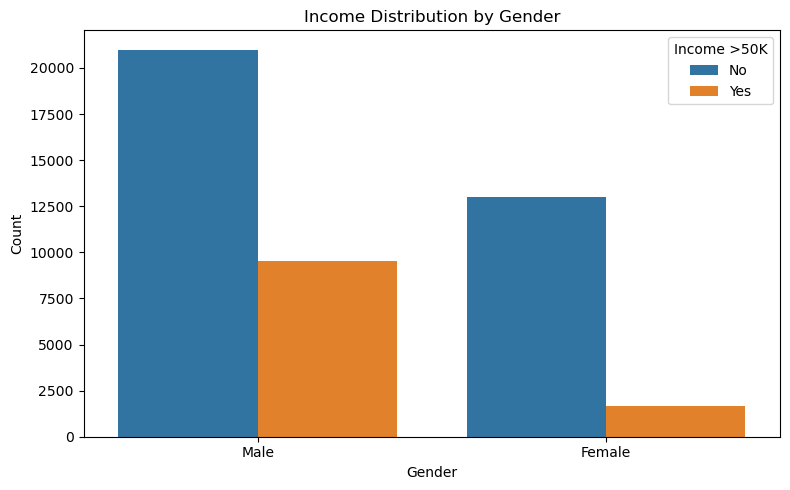

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="sex",
    hue="income_binary"
)

plt.title("Income Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.legend(
    title="Income >50K",
    labels=["No","Yes"]
)

plt.tight_layout()

plt.savefig(
    "figures_pdf/fig1_income_distribution_by_gender.pdf"
)

plt.show()

In [12]:
import os

print(os.listdir("figures_pdf"))

['fig1_income_distribution_by_gender.pdf']


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Features
X = df.drop(columns=["income", "income_binary"])

# Target
y = df["income_binary"]

# Save protected attributes
sex = df["sex"]
race = df["race"]

# Detect column types
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

# Train/Test split
X_train, X_test, y_train, y_test, sex_train, sex_test, race_train, race_test = train_test_split(
    X,
    y,
    sex,
    race,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Categorical Columns:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Numerical Columns:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Train Shape: (31655, 14)
Test Shape: (13567, 14)


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

print("Accuracy :", round(lr_accuracy,4))
print("Precision:", round(lr_precision,4))
print("Recall   :", round(lr_recall,4))
print("F1 Score :", round(lr_f1,4))

Accuracy : 0.8445
Precision: 0.7325
Recall   : 0.5866
F1 Score : 0.6515


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Accuracy :", round(rf_accuracy,4))
print("Precision:", round(rf_precision,4))
print("Recall   :", round(rf_recall,4))
print("F1 Score :", round(rf_f1,4))

Accuracy : 0.8477
Precision: 0.7295
Recall   : 0.6127
F1 Score : 0.666


In [16]:
performance_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1
    ]
})

performance_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.844476,0.732541,0.586556,0.65147
1,Random Forest,0.847719,0.729462,0.612731,0.66602


In [17]:
performance_table.to_csv(
    "tables_csv/table2_model_performance.csv",
    index=False
)

print("Table saved successfully")

Table saved successfully


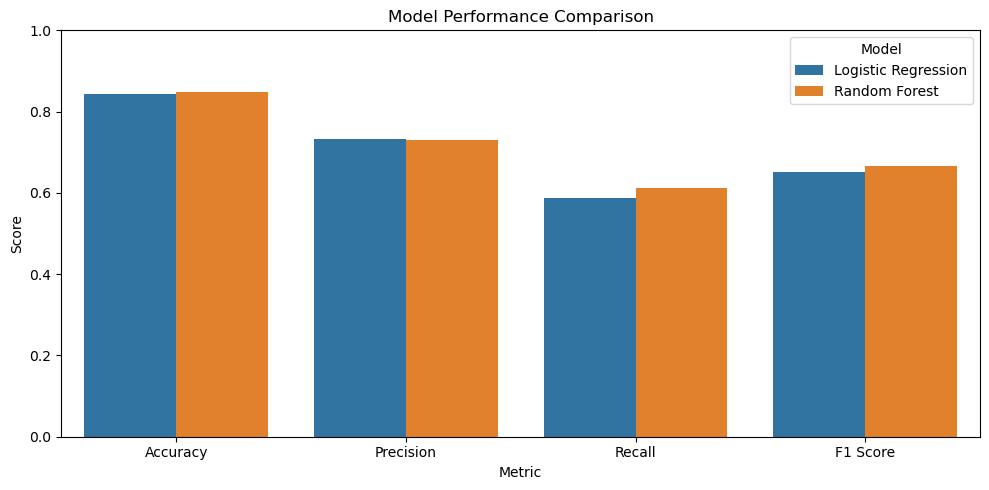

In [18]:
performance_melted = performance_table.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=performance_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Model Performance Comparison")
plt.ylim(0,1)

plt.tight_layout()

plt.savefig(
    "figures_pdf/fig2_model_performance_comparison.pdf"
)

plt.show()

In [19]:
from sklearn.metrics import confusion_matrix

def fairness_metrics(y_true, y_pred, sensitive_attr, privileged_group):
    
    data = pd.DataFrame({
        "y_true": y_true.values,
        "y_pred": y_pred,
        "group": sensitive_attr.values
    })

    rows = []

    for group in data["group"].unique():

        group_data = data[data["group"] == group]

        tn, fp, fn, tp = confusion_matrix(
            group_data["y_true"],
            group_data["y_pred"],
            labels=[0,1]
        ).ravel()

        selection_rate = group_data["y_pred"].mean()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        rows.append({
            "Group": group,
            "Count": len(group_data),
            "Selection Rate": selection_rate,
            "True Positive Rate": tpr,
            "False Positive Rate": fpr
        })

    result = pd.DataFrame(rows)

    privileged_rate = result.loc[
        result["Group"] == privileged_group,
        "Selection Rate"
    ].values[0]

    result["Statistical Parity Difference"] = (
        result["Selection Rate"] - privileged_rate
    )

    return result

In [20]:
gender_fairness_table = fairness_metrics(
    y_test,
    rf_predictions,
    sex_test,
    privileged_group="Male"
)

gender_fairness_table

,Group,Count,Selection Rate,True Positive Rate,False Positive Rate,Statistical Parity Difference
0,Female,4390,0.083371,0.529412,0.024742,-0.184472
1,Male,9177,0.267844,0.627630,0.105613,0.000000


In [21]:
gender_fairness_table.to_csv(
    "tables_csv/table3_gender_fairness_metrics.csv",
    index=False
)

print("Gender fairness table saved")

Gender fairness table saved


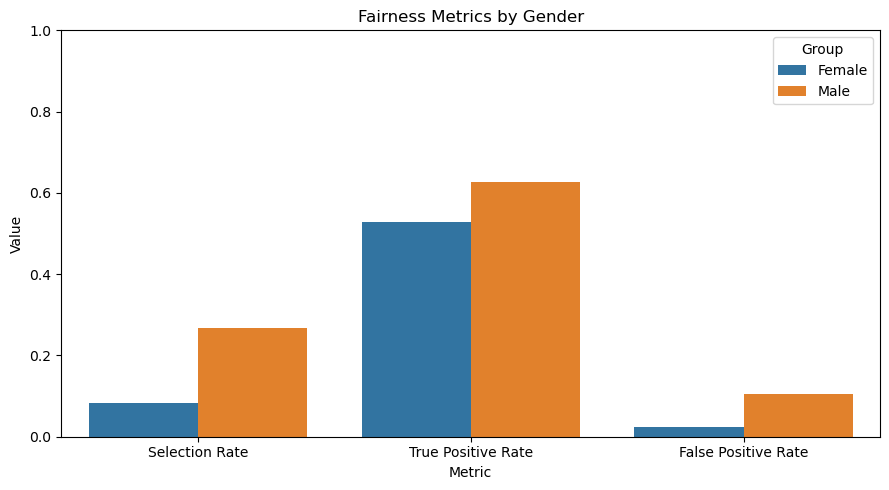

In [22]:
gender_plot = gender_fairness_table.melt(
    id_vars="Group",
    value_vars=[
        "Selection Rate",
        "True Positive Rate",
        "False Positive Rate"
    ],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(9,5))

sns.barplot(
    data=gender_plot,
    x="Metric",
    y="Value",
    hue="Group"
)

plt.title("Fairness Metrics by Gender")
plt.ylim(0,1)

plt.tight_layout()

plt.savefig(
    "figures_pdf/fig3_fairness_metrics_gender.pdf"
)

plt.show()

In [23]:
race_fairness_table = fairness_metrics(
    y_test,
    rf_predictions,
    race_test,
    privileged_group="White"
)

race_fairness_table

,Group,Count,Selection Rate,True Positive Rate,False Positive Rate,Statistical Parity Difference
0,White,11680,0.222688,0.617111,0.081803,0.000000
1,Black,1253,0.084597,0.522876,0.023636,-0.138091
2,Amer-Indian-Eskimo,146,0.116438,0.571429,0.068182,-0.106250
3,Asian-Pac-Islander,389,0.231362,0.632075,0.081272,0.008674
4,Other,99,0.101010,0.533333,0.023810,-0.121678


In [24]:
race_fairness_table.to_csv(
    "tables_csv/table4_race_fairness_metrics.csv",
    index=False
)

print("Race fairness table saved")

Race fairness table saved


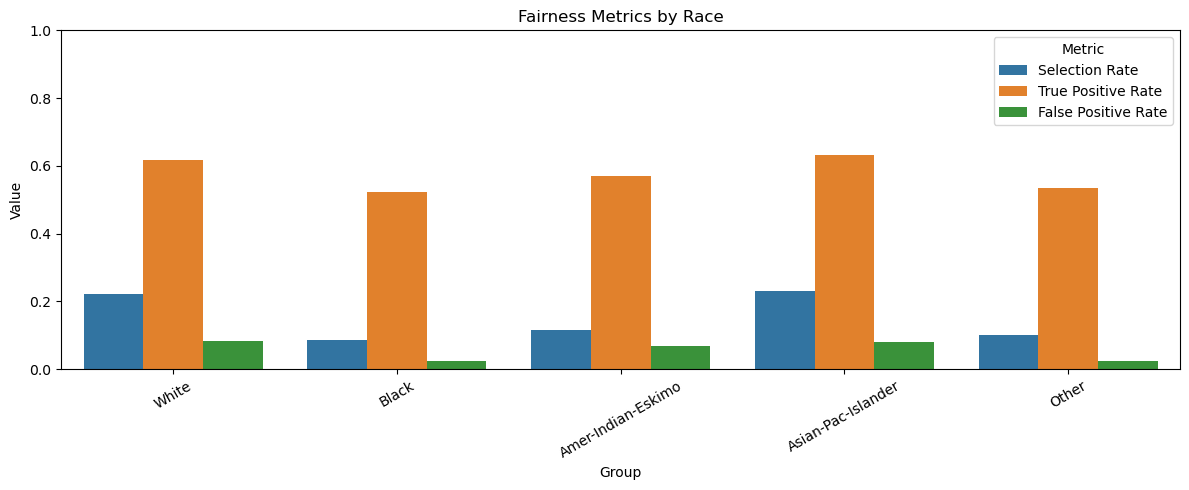

In [25]:
race_plot = race_fairness_table.melt(
    id_vars="Group",
    value_vars=[
        "Selection Rate",
        "True Positive Rate",
        "False Positive Rate"
    ],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(12,5))

sns.barplot(
    data=race_plot,
    x="Group",
    y="Value",
    hue="Metric"
)

plt.title("Fairness Metrics by Race")

plt.xticks(rotation=30)

plt.ylim(0,1)

plt.tight_layout()

plt.savefig(
    "figures_pdf/fig4_fairness_metrics_race.pdf"
)

plt.show()

In [26]:
# Remove protected attributes
X_fair = df.drop(
    columns=[
        "income",
        "income_binary",
        "sex",
        "race"
    ]
)

y_fair = df["income_binary"]

categorical_cols_fair = X_fair.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols_fair = X_fair.select_dtypes(
    exclude=["object"]
).columns.tolist()

X_train_fair, X_test_fair, y_train_fair, y_test_fair, sex_train_fair, sex_test_fair = train_test_split(
    X_fair,
    y_fair,
    df["sex"],
    test_size=0.30,
    random_state=42,
    stratify=y_fair
)

preprocessor_fair = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols_fair),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_fair)
    ]
)

In [27]:
fair_model = Pipeline([
    ("preprocessor", preprocessor_fair),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

fair_model.fit(
    X_train_fair,
    y_train_fair
)

fair_predictions = fair_model.predict(
    X_test_fair
)

fair_accuracy = accuracy_score(
    y_test_fair,
    fair_predictions
)

print("Fair Model Accuracy:", fair_accuracy)

Fair Model Accuracy: 0.8460234392275374


In [28]:
mitigated_gender_fairness = fairness_metrics(
    y_test_fair,
    fair_predictions,
    sex_test_fair,
    privileged_group="Male"
)

mitigated_gender_fairness

,Group,Count,Selection Rate,True Positive Rate,False Positive Rate,Statistical Parity Difference
0,Female,4390,0.089522,0.549020,0.029124,-0.179847
1,Male,9177,0.269369,0.627279,0.107984,0.000000


In [29]:
baseline_spd = abs(-0.184472)
mitigated_spd = abs(-0.179847)

mitigation_table = pd.DataFrame({
    "Model":[
        "Baseline Random Forest",
        "Fairness-aware Random Forest"
    ],
    "Accuracy":[
        0.8477,
        fair_accuracy
    ],
    "Absolute SPD":[
        baseline_spd,
        mitigated_spd
    ]
})

mitigation_table

,Model,Accuracy,Absolute SPD
0,Baseline Random Forest,0.847700,0.184472
1,Fairness-aware Random Forest,0.846023,0.179847


In [30]:
mitigation_table.to_csv(
    "tables_csv/table5_mitigation_comparison.csv",
    index=False
)

print("Table 5 saved")

Table 5 saved


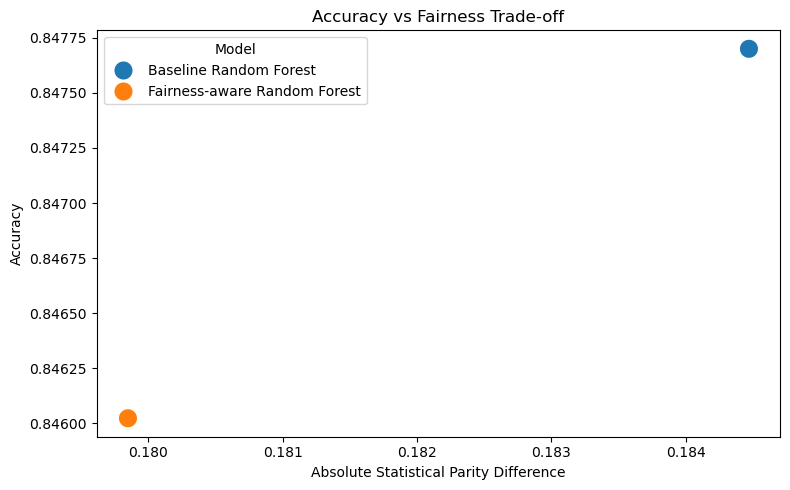

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=mitigation_table,
    x="Absolute SPD",
    y="Accuracy",
    hue="Model",
    s=200
)

plt.title(
    "Accuracy vs Fairness Trade-off"
)

plt.xlabel(
    "Absolute Statistical Parity Difference"
)

plt.ylabel(
    "Accuracy"
)

plt.tight_layout()

plt.savefig(
    "figures_pdf/fig5_tradeoff_accuracy_fairness.pdf"
)

plt.show()

In [32]:
import os

print("PDF Figures")
print(os.listdir("figures_pdf"))

print("\nCSV Tables")
print(os.listdir("tables_csv"))

PDF Figures
['fig1_income_distribution_by_gender.pdf', 'fig2_model_performance_comparison.pdf', 'fig3_fairness_metrics_gender.pdf', 'fig4_fairness_metrics_race.pdf', 'fig5_tradeoff_accuracy_fairness.pdf']

CSV Tables
['table1_dataset_summary.csv', 'table2_model_performance.csv', 'table3_gender_fairness_metrics.csv', 'table4_race_fairness_metrics.csv', 'table5_mitigation_comparison.csv']
